## Pytorch Workflow 


In [1]:
import torch  # Core PyTorch library for tensors and GPU-accelerated computation

from torch import nn  # Provides neural‑network layers, loss functions, and model components

import matplotlib.pyplot as plt  # Used for plotting data and visualizing model results

torch.__version__  # Displays the installed PyTorch version (useful for debugging and CUDA checks)


'2.5.1+cu121'

## 1. Data (preparing and loading)

In [2]:
weight = 0.7          # define the slope of the linear function
bias = 0.3            # define the intercept added to the linear function

start = 0             # lower bound for generating input values
end = 1               # upper bound for generating input values (not included)
step = 0.02           # increment between consecutive input values
X = torch.arange(start, end, step).unsqueeze(dim=1)  # create a column vector of evenly spaced inputs
y = weight * X + bias                                # compute target outputs using the linear equation y = mX + b

X[:10], y[:10], len(X), len(y)  # display first 10 samples and confirm matching lengths


(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]),
 50,
 50)

In [3]:
len(X), len(y)  # return the number of samples in X and y to confirm they match


(50, 50)

## Splitting Data into Training and Test Sets (one of the most important concepts in machine learning)

### Let's create a training and test set with our data


In [4]:
train_split = int(0.8 * len(X))   # calculate the index that marks 80% of the dataset for training
train_split                        # output the computed split index for verification


40

In [5]:
X_train, y_train = X[:train_split], y[:train_split]   # take the first 80% of X and y as the training set

X_test, y_test = X[train_split:], y[train_split:]     # take the remaining 20% of X and y as the test set

len(X_train), len(y_train), len(X_test), len(y_test)  # confirm that train/test splits have the expected sizes


(40, 40, 10, 10)

In [6]:
def plot_predictions(
    train_data=X_train,          # default training input values
    train_labels=y_train,        # default training target values
    test_data=X_test,            # default test input values
    test_labels=y_test,          # default test target values
    prediction=None              # optional model predictions for the test set
):
    plt.figure(figsize=(10, 7))  # create a plotting canvas with a defined size

    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")  
    # plot training points in blue

    plt.scatter(test_data, test_labels, c="g", s=4, label="Test data")        
    # plot test points in green

    if prediction is not None:                                             
        plt.scatter(test_data, prediction, c="r", s=4, label="Predictions")  
        # plot model predictions in red if provided

    plt.legend(fontsize=14)  # display the legend with larger text
    plt.show()               # render the final plot


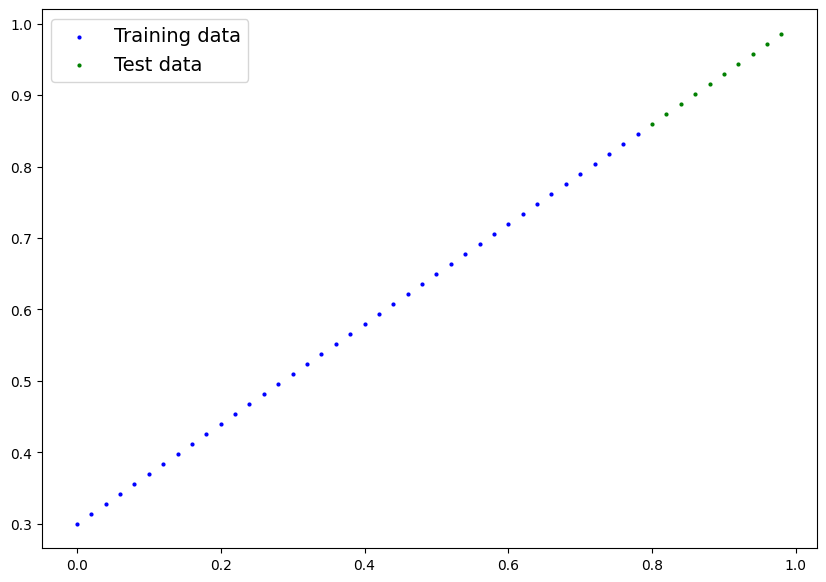

In [218]:
plot_predictions();

## 2. Build Model

In [7]:
# Create a Linear Regression model class
class LinearRegressionModel(nn.Module):  # define a model that inherits from PyTorch's base neural network module
    def __init__(self):  # initialize model components
        super().__init__()  # call the parent class constructor
        
        self.weights = nn.Parameter(  # create a learnable weight parameter
            torch.randn(1, dtype=torch.float),  # initialize weight with a random float32 value
            requires_grad=True  # allow this parameter to be updated during training
        )

        self.bias = nn.Parameter(  # create a learnable bias parameter
            torch.randn(1, dtype=torch.float),  # initialize bias with a random float32 value
            requires_grad=True  # allow this parameter to be updated during training
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:  # define how the model transforms input x
        return self.weights * x + self.bias  # apply the linear equation y = m*x + b


### PyTorch model building essentials 


In [8]:
torch.manual_seed(42)  # set a fixed random seed so weight and bias initialization is reproducible

model_0 = LinearRegressionModel()  # create a new instance of our linear regression model class

list(model_0.parameters())  # display the model’s learnable parameters (weight and bias)


[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [9]:
# List named parameters  
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

### Making prediction using `torch.inference_mode()`

In [10]:
X_test, y_test

(tensor([[0.8000],
         [0.8200],
         [0.8400],
         [0.8600],
         [0.8800],
         [0.9000],
         [0.9200],
         [0.9400],
         [0.9600],
         [0.9800]]),
 tensor([[0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]))

In [11]:
y_preds = model_0(X_test)  # run the model on the test inputs to generate predicted outputs
y_preds                     # display the predicted values returned by the model


tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]], grad_fn=<AddBackward0>)

In [12]:
with torch.inference_mode():        # disable gradient tracking for faster, memory‑efficient inference
    y_preds = model_0(X_test)       # generate predictions from the model without building a computation graph

with torch.no_grad():               # another way to disable gradient tracking during evaluation
    y_preds = model_0(X_test)       # run the model again to produce predictions without storing gradients

y_preds                              # display the final predicted values


tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

In [13]:
y_test

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

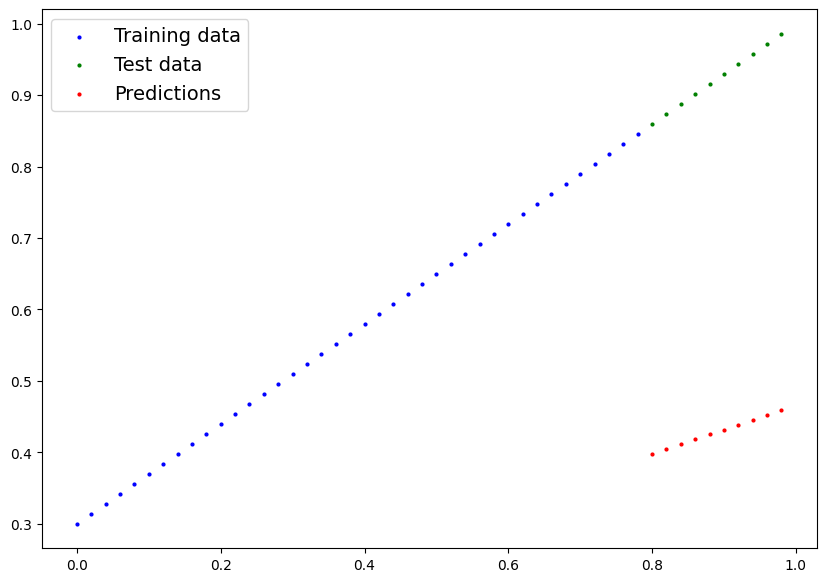

In [14]:
plot_predictions(prediction=y_preds)

## 3. Train model 

In [15]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [16]:
# List named parameters 
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [17]:
loss_fn = nn.L1Loss()  # define the loss function (L1/MAE) to measure prediction error

optimizer = torch.optim.SGD(                     # create the optimizer that updates model parameters
    params=model_0.parameters(),                 # specify which parameters the optimizer should adjust
    lr=0.01                                      # set the learning rate controlling update step size
)


### Building a training loop (and a testing loop) in Pytorch

In [18]:
torch.manual_seed(42)  # ensure reproducible weight initialization and training behavior

epochs = 200  # number of full passes the model will make over the training dataset

train_loss_values = []  # list to store training loss values for plotting
test_loss_values = []   # list to store test loss values for plotting
epoch_count = []        # list to store epoch numbers for tracking progress

for epoch in range(epochs):  # loop through the training process for the defined number of epochs
    ### Training

    model_0.train()  # set the model to training mode (enables gradient updates)

    y_pred = model_0(X_train)  # run a forward pass to get predictions on the training data

    loss = loss_fn(y_pred, y_train)  # compute training loss by comparing predictions to true labels

    optimizer.zero_grad()  # reset gradients from the previous step to avoid accumulation

    loss.backward()  # compute gradients of the loss with respect to model parameters

    optimizer.step()  # update model parameters using the computed gradients

    ### Testing

    model_0.eval()  # switch model to evaluation mode (disables dropout, etc.)

    with torch.inference_mode():  # disable gradient tracking for faster, memory‑efficient evaluation
        test_pred = model_0(X_test)  # generate predictions on the test dataset

        test_loss = loss_fn(test_pred, y_test.type(torch.float))  # compute test loss using matching tensor types

        if epoch % 10 == 0:  # log progress every 10 epochs
            epoch_count.append(epoch)  # record the current epoch number
            train_loss_values.append(loss.detach().numpy())  # store training loss as a NumPy value
            test_loss_values.append(test_loss.detach().numpy())  # store test loss as a NumPy value
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss}")  # display progress


Epoch: 0 | MAE Train Loss: 0.31288138031959534 | MAE Test Loss: 0.48106518387794495
Epoch: 10 | MAE Train Loss: 0.1976713240146637 | MAE Test Loss: 0.3463551998138428
Epoch: 20 | MAE Train Loss: 0.08908725529909134 | MAE Test Loss: 0.21729660034179688
Epoch: 30 | MAE Train Loss: 0.053148526698350906 | MAE Test Loss: 0.14464017748832703
Epoch: 40 | MAE Train Loss: 0.04543796554207802 | MAE Test Loss: 0.11360953003168106
Epoch: 50 | MAE Train Loss: 0.04167863354086876 | MAE Test Loss: 0.09919948130846024
Epoch: 60 | MAE Train Loss: 0.03818932920694351 | MAE Test Loss: 0.08886633068323135
Epoch: 70 | MAE Train Loss: 0.03476089984178543 | MAE Test Loss: 0.0805937647819519
Epoch: 80 | MAE Train Loss: 0.03132382780313492 | MAE Test Loss: 0.07232122868299484
Epoch: 90 | MAE Train Loss: 0.02788739837706089 | MAE Test Loss: 0.06473556160926819
Epoch: 100 | MAE Train Loss: 0.024458957836031914 | MAE Test Loss: 0.05646304413676262
Epoch: 110 | MAE Train Loss: 0.021020207554101944 | MAE Test Loss:

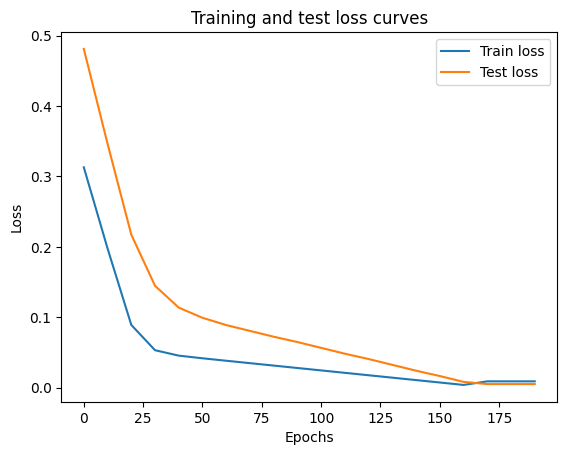

In [19]:
plt.plot(epoch_count, train_loss_values, label="Train loss")  # plot training loss values across recorded epochs

plt.plot(epoch_count, test_loss_values, label="Test loss")    # plot test loss values across the same epochs

plt.title("Training and test loss curves")                    # add a descriptive title to the plot

plt.ylabel("Loss")                                            # label the y‑axis to indicate loss values

plt.xlabel("Epochs")                                          # label the x‑axis to show epoch numbers

plt.legend()                                                  # display the legend to distinguish the two curves


In [20]:
with torch.inference_mode():          # disable gradient tracking to make prediction faster and memory‑efficient
    y_preds_new = model_0(X_test)     # generate new predictions from the model using the test inputs


In [ ]:
model_0.state_dict()  # display the model’s learned parameters (weights and bias) as an ordered dictionary


OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [23]:
weight, bias 

(0.7, 0.3)

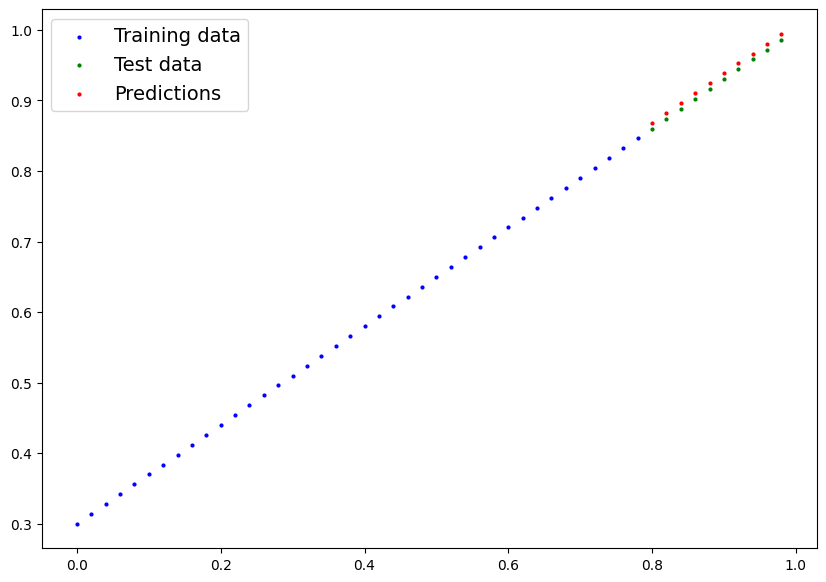

In [24]:
plot_predictions(prediction=y_preds_new)  # visualize training data, test data, and the model’s predicted test outputs


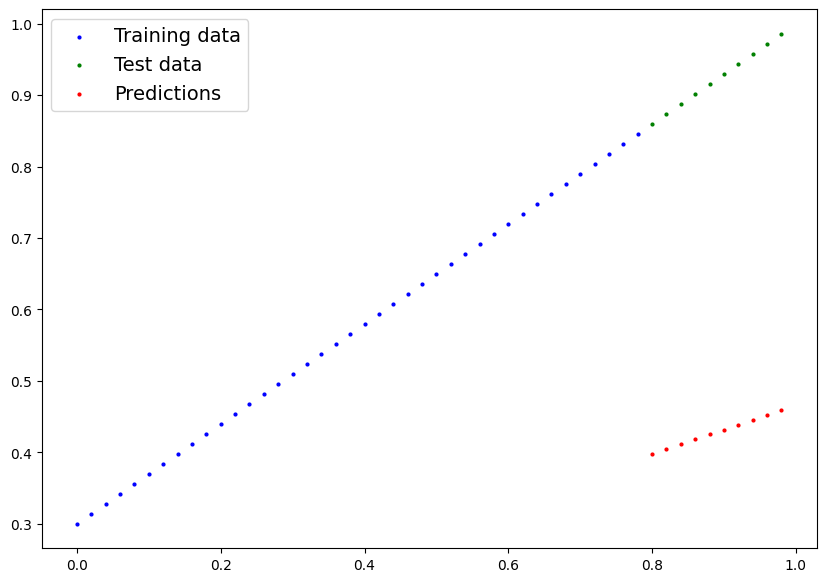

In [25]:
plot_predictions(prediction=y_preds)

### Saving a Pytorch model state_dict()

In [26]:
from pathlib import Path  # import Path to handle filesystem paths in an OS‑independent way

MODEL_PATH = Path("models")  # define a path object pointing to a folder named "models"
MODEL_PATH.mkdir(parents=True, exist_ok=True)  # create the folder if it doesn't exist (including parent dirs)

MODEL_NAME = "01_pytorch_workflow_model_0.pth"  # specify the filename for saving the model
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME       # combine folder path and filename into a full save path

print(f"Saving model to: {MODEL_SAVE_PATH}")  # show where the model will be saved
torch.save(obj=model_0.state_dict(),          # save only the model’s learned parameters (state_dict)
           f=MODEL_SAVE_PATH)                 # write them to the specified file path


Saving model to: models\01_pytorch_workflow_model_0.pth


In [27]:
ls -l models\01_pytorch_workflow_model_0.pth

 Volume in drive C is OS
 Volume Serial Number is 244C-1A86

 Directory of c:\Users\men_l\Downloads\pytorch


 Directory of c:\Users\men_l\Downloads\pytorch\models

02/01/2026  01:10 PM             1,680 01_pytorch_workflow_model_0.pth
               1 File(s)          1,680 bytes
               0 Dir(s)  86,186,921,984 bytes free


File Not Found


### Loading a saved PyTorch model's state_dict()

In [28]:
loaded_model_0 = LinearRegressionModel()  # create a fresh model instance initialized with new random weights

loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))  # load the saved trained weights into this new model instance


C:\Users\men_l\AppData\Local\Temp\ipykernel_16024\600071850.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

In [29]:
loaded_model_0.state_dict()  # view the trained model’s parameters (weights and bias) that were loaded from disk


OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [30]:
loaded_model_0.eval()  # switch the loaded model into evaluation mode (disables training-specific behavior)

with torch.inference_mode():  # turn off gradient tracking for efficient inference
    loaded_model_preds = loaded_model_0(X_test)  # generate predictions on the test data using the loaded model


In [31]:
# Compare previous model predictions with loaded model predictions (these should be the same)
y_preds == loaded_model_preds

tensor([[False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False]])

In [32]:
y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

In [33]:
model_0.eval()                     # set the model to evaluation mode (disables training-specific behavior)

with torch.inference_mode():       # turn off gradient tracking for efficient, memory‑safe inference
    y_preds = model_0(X_test)      # run the model on the test inputs to generate predictions

y_preds                            # display the predicted output values


tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

In [246]:
# Compare previous model predictions with loaded model predictions (these should be the same)
y_preds == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

### 6. Putting it all together

In [34]:
# Import PyTorch and Matplotlib  
import torch                               # load the main PyTorch library for tensors and computation
from torch import nn                        # import nn module, which provides neural‑network building blocks
import matplotlib.pyplot as plt             # import plotting library for visualizing data and model results
torch.__version__                           # display the installed PyTorch version


'2.5.1+cu121'

In [35]:
device = "cuda" if torch.cuda.is_available() else "cpu"  # choose GPU if available, otherwise fall back to CPU

print(f"Using device: {device}")  # display which device the model and tensors will run on


Using device: cuda


In [36]:
!nvidia-smi 

Sun Feb  1 13:14:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 555.97                 Driver Version: 555.97         CUDA Version: 12.5     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 2060      WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   43C    P8             12W /   95W |       0MiB /   6144MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### 6.1 Data 

In [37]:
# Create weight and bias  
weight = 0.7                     # define the slope of the linear relationship
bias = 0.3                       # define the intercept added to the linear function

# Create range values  
start = 0                        # starting value for generating input data
end = 1                          # ending value (non‑inclusive) for generating input data
step = 0.02                      # spacing between consecutive values in the range

# Create X and y (features and labels)
X = torch.arange(start, end, step).unsqueeze(dim=1)   # generate input values and reshape into a column vector
y = weight * X + bias                                 # compute target values using the linear equation y = mX + b

X[:10], y[:10]                 # preview the first 10 samples of inputs and outputs


(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [38]:
# Split data  
train_split = int(0.8 * len(X))                     # calculate index representing 80% of the dataset for training

X_train, y_train = X[:train_split], y[:train_split] # take the first 80% of X and y as training data

X_test, y_test = X[train_split:], y[train_split:]   # take the remaining 20% of X and y as test data

len(X_train), len(y_train), len(X_test), len(y_test)  # display the sizes of each split to verify correctness


(40, 40, 10, 10)

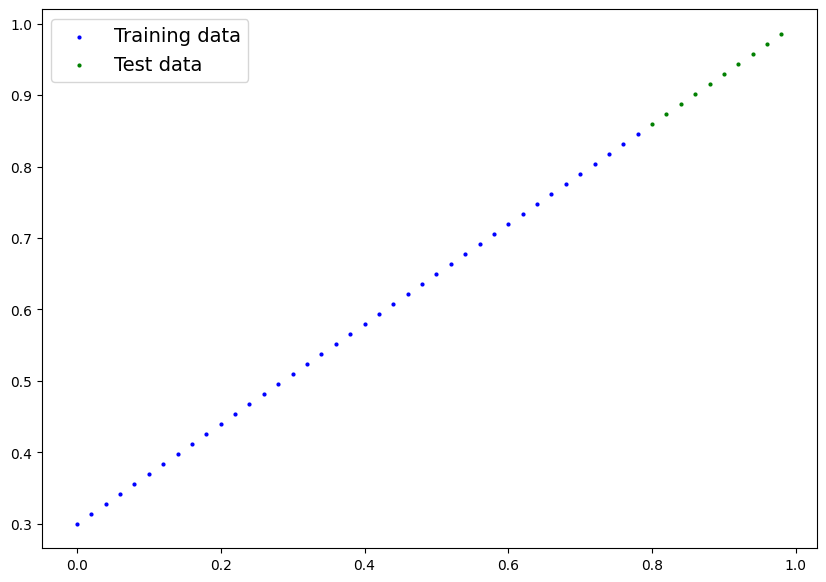

In [39]:
# Note: If you've reset your runtime, this function won't work, 
# you'll have to rerun the cell where plot_predictions() was originally defined
plot_predictions(X_train, y_train, X_test, y_test)  # visualize training data, test data, and model predictions


### 6.2 Building a PyTorch Linear Model 

In [40]:
# Subclass nn.Module to make our model
class LinearRegressionModelV2(nn.Module):                     # define a new model class that inherits from nn.Module
    def __init__(self):
        super().__init__()                                    # initialize the parent nn.Module class
        self.linear_layer = nn.Linear(in_features=1,          # create a linear layer that takes 1 input feature
                                      out_features=1)         # and outputs 1 predicted value
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:        # define how data flows through the model during a forward pass
        return self.linear_layer(x)                           # pass input x through the linear layer to get predictions

torch.manual_seed(42)                                         # set seed so model initialization is reproducible
model_1 = LinearRegressionModelV2()                           # create an instance of the linear regression model
model_1, model_1.state_dict()                                 # display the model architecture and its initial parameters


(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [254]:
X_train[:5], y_train[:5]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560]]))

In [255]:
# Check model device
next(model_1.parameters()).device

device(type='cpu')

In [41]:
model_1.to(device)                          # move the model's parameters to the selected device (GPU or CPU)

next(model_1.parameters()).device           # check and display which device the model's parameters are currently on


device(type='cuda', index=0)

### 6.3 Trainings 

In [42]:
# Create loss function
loss_fn = nn.L1Loss()  # use Mean Absolute Error (L1) to measure how far predictions are from true values

# Create optimizer
optimizer = torch.optim.SGD(params=model_1.parameters(),  # tell SGD which model parameters to update during training
                            lr=0.01)                     # set the learning rate controlling step size in optimization


In [44]:
torch.manual_seed(42)                           # set random seed so model initialization and training are reproducible

epochs = 1000                                   # define how many times the model will iterate over the training data

# Put data on the available device
X_train = X_train.to(device)                    # move training features to GPU/CPU
X_test = X_test.to(device)                      # move test features to GPU/CPU
y_train = y_train.to(device)                    # move training labels to GPU/CPU
y_test = y_test.to(device)                      # move test labels to GPU/CPU

for epoch in range(epochs):                     # loop through the training process for the specified number of epochs
    model_1.train()                             # set model to training mode (enables gradient computation)

    y_pred = model_1(X_train)                   # run a forward pass to get predictions on training data

    loss = loss_fn(y_pred, y_train)             # compute training loss comparing predictions to true labels

    optimizer.zero_grad()                       # reset gradients from the previous iteration

    loss.backward()                             # compute gradients of the loss with respect to model parameters

    optimizer.step()                            # update model parameters using the optimizer

    model_1.eval()                              # switch model to evaluation mode (disables dropout, etc.)

    with torch.inference_mode():                # disable gradient tracking for faster, safer inference
        test_pred = model_1(X_test)             # generate predictions on the test data
        test_loss = loss_fn(test_pred, y_test)  # compute test loss

    if epoch % 100 == 0:                        # print progress every 100 epochs
        print(f"Epoch: {epoch} | Train loss: {loss} | Test loss: {test_loss}")


Epoch: 0 | Train loss: 0.0012645035749301314 | Test loss: 0.013801801018416882
Epoch: 100 | Train loss: 0.0012645035749301314 | Test loss: 0.013801801018416882
Epoch: 200 | Train loss: 0.0012645035749301314 | Test loss: 0.013801801018416882
Epoch: 300 | Train loss: 0.0012645035749301314 | Test loss: 0.013801801018416882
Epoch: 400 | Train loss: 0.0012645035749301314 | Test loss: 0.013801801018416882
Epoch: 500 | Train loss: 0.0012645035749301314 | Test loss: 0.013801801018416882
Epoch: 600 | Train loss: 0.0012645035749301314 | Test loss: 0.013801801018416882
Epoch: 700 | Train loss: 0.0012645035749301314 | Test loss: 0.013801801018416882
Epoch: 800 | Train loss: 0.0012645035749301314 | Test loss: 0.013801801018416882
Epoch: 900 | Train loss: 0.0012645035749301314 | Test loss: 0.013801801018416882


In [45]:
# Find our model's learned parameters
from pprint import pprint  # import pprint for cleaner, more readable printing of dictionaries

print("The model learned the following values for weights and bias:")  # announce learned parameter values
pprint(model_1.state_dict())                                          # display the model’s trained weights and bias

print("\nAnd the original values for weights and bias are:")          # announce the true underlying values
print(f"weights: {weight}, bias: {bias}")                             # print the original weight and bias used to generate data


The model learned the following values for weights and bias:
OrderedDict([('linear_layer.weight', tensor([[0.6968]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.3025], device='cuda:0'))])

And the original values for weights and bias are:
weights: 0.7, bias: 0.3


### Making predictions 

In [46]:
# Turn model into evaluation mode
model_1.eval()                          # switch the model to evaluation mode (disables training-specific behaviors)

# Make predictions on the test data
with torch.inference_mode():            # disable gradient tracking for faster, memory‑efficient inference
    y_preds = model_1(X_test)           # run the model on the test inputs to generate predictions

y_preds                                 # display the predicted values


tensor([[0.8600],
        [0.8739],
        [0.8878],
        [0.9018],
        [0.9157],
        [0.9296],
        [0.9436],
        [0.9575],
        [0.9714],
        [0.9854]], device='cuda:0')

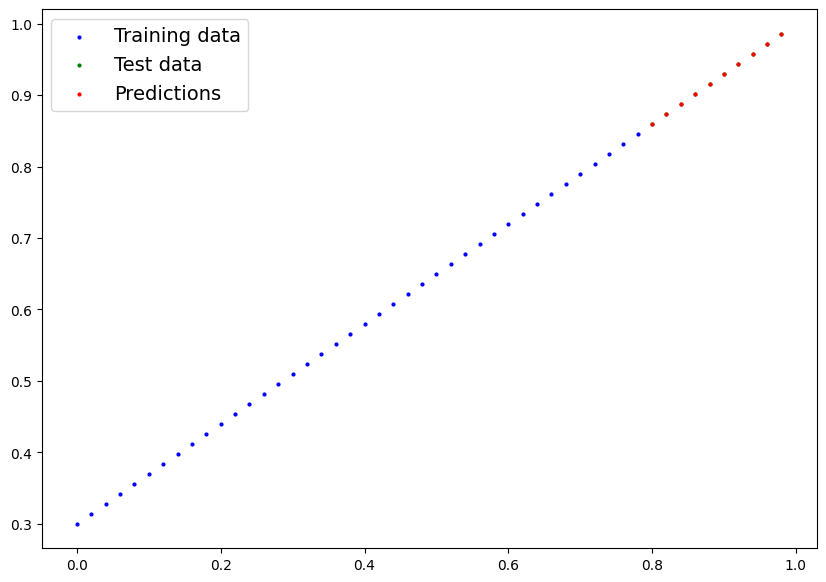

In [263]:
# plot_predictions(predictions=y_preds) # -> won't work... data not on CPU

# Put data on the CPU and plot it
plot_predictions(prediction=y_preds.cpu())


### Saving and Loading a Model

In [47]:
from pathlib import Path                           # import Path to work with filesystem paths in an OS‑independent way

MODEL_PATH = Path("models")                        # define a folder named "models" to store saved model files
MODEL_PATH.mkdir(parents=True, exist_ok=True)      # create the folder if it doesn't already exist (including parents)

MODEL_NAME = "01_pytorch_workflow_model_1.pth"     # choose a filename for the saved model state dictionary
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME          # build the full path to the model file inside the models folder

print(f"Saving model to : {MODEL_SAVE_PATH}")       # print the exact file path where the model will be saved
torch.save(obj=model_1.state_dict(),               # save only the model's learned parameters (state_dict)
           f=MODEL_SAVE_PATH)                      # write them to the specified file path


Saving model to : models\01_pytorch_workflow_model_1.pth


In [48]:
# Instantiate a fresh instance of LinearRegressionModelV2 
loaded_model_1 = LinearRegressionModelV2()                     # create a new untrained model with the same architecture

# Load model state dict  
loaded_model_1.load_state_dict(torch.load(MODEL_SAVE_PATH))    # load the saved trained weights into the new model instance

# Put model to target device (if your data is on GPU, model will have to be on GPU to make predictions) 
loaded_model_1.to(device)                                      # move the loaded model to the same device as the data

print(f"Loaded model: \n{loaded_model_1}")                     # print the model structure to confirm successful loading
print(f"Model on device: \n{next(loaded_model_1.parameters()).device}")  # show which device the model's parameters live on


Loaded model: 
LinearRegressionModelV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)
Model on device: 
cuda:0


C:\Users\men_l\AppData\Local\Temp\ipykernel_16024\3521905478.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model_1.load_state_dict(torch.load(MODEL_SAVE_PATH)) 

In [267]:
next(loaded_model_1.parameters()).device

device(type='cuda', index=0)

In [268]:
loaded_model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.3025], device='cuda:0'))])

In [49]:
# Evaluate loaded model  
loaded_model_1.eval()                               # switch the loaded model into evaluation mode

with torch.inference_mode():                        # disable gradient tracking for efficient inference
    loaded_model_1_preds = loaded_model_1(X_test)   # generate predictions using the loaded model on test data

y_preds == loaded_model_1_preds                     # compare original model predictions with loaded model predictions


tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]], device='cuda:0')